# Black & Scholes Option Pricing based on Artificial Neural Network

Coding Based on the following Article

Machine Learning in Finance:

The Case of Deep Learning for Option Pricing

Robert Culkin & Sanjiv R. Das

Santa Clara University

## Simulation Data Generator

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.getcwd() # Current Working directory

'/content'

In [3]:
# Create Working Directory if necessary

PROJECT_ROOT_DIR = "/content/drive/MyDrive/Colab Notebooks/Cours MAE"

os.makedirs(PROJECT_ROOT_DIR, exist_ok=True)

# Change the current working directory

os.chdir(PROJECT_ROOT_DIR)

os.getcwd() # Current Working directory

'/content/drive/MyDrive/Colab Notebooks/Cours MAE'

In [4]:
import numpy as np
import pandas as pd

from random import random

In [5]:
import sys

sys.path.append('./library')

from ModuleBlackScholes import bs_call #Importation bs_call

In [6]:
# Train / Test Data Size

N_train = 240000
N_test = 60000

# Robert Culkin Paper Stock Data parameters

S_Min = 10 # Stock Price
S_Max = 500

# K_Min = 7
# K_Max = 650

KvsS_Factor = 0.25

sigma_Min = 5/100 # Volatility
sigma_Max = 90/100

T_Min = 1/360 # 1 Day
T_Max = 3 # 3 years

r_Min = 1/100 # $ Risk Free Rate
r_Max = 3/100 # $ Risk Free Rate

q_Min = 0/100 # Dividend Rate
q_Max = 3/100 # Dividend Rate

In [7]:
# BS Test: a sample

S = (S_Max - S_Min)*random() + S_Min
K_Min = (1-KvsS_Factor)*S
K_Max = (1+KvsS_Factor)*S
K = (K_Max - K_Min)*random() + K_Min

sigma = (sigma_Max - sigma_Min)*random() + sigma_Min
T = (T_Max - T_Min)*random() + T_Min
r = (r_Max - r_Min)*random() + r_Min
q = (q_Max - q_Min)*random() + q_Min

print("S = ", S)
print("K = ", K)
print("sigma = ", "%.2f" % (sigma*100), "%")
print("T = ", T)
print("r = ", r)
print("q = ", q)

c = bs_call(S,K,sigma,T,r,q) # BS Ca  Option price
print("Call Price = ", c)
print("Call Price / K = %.5f" % (c/K))

S =  310.7541599389529
K =  257.49548139886474
sigma =  35.06 %
T =  1.766031907329623
r =  0.028373375665495
q =  0.006214141346999646
Call Price =  87.88804664001688
Call Price / K = 0.34132


### Train and Test Data Generation

In [8]:
X_train = np.zeros((N_train,6))
X_test = np.zeros((N_test,6))
y_train = np.zeros((N_train,1))
y_test = np.zeros((N_test,1))

In [9]:
# X_train, y_train Loop

price_limite = 0.25 # Retaining only options with c/K >= price_limit

In [10]:
i = 0
while i < N_train:

    S = (S_Max - S_Min)*random() + S_Min
    K_Min = (1-KvsS_Factor)*S
    K_Max = (1+KvsS_Factor)*S
    K = (K_Max - K_Min)*random() + K_Min
    sigma = (sigma_Max - sigma_Min)*random() + sigma_Min
    T = (T_Max - T_Min)*random() + T_Min
    r = (r_Max - r_Min)*random() + r_Min
    q = (q_Max - q_Min)*random() + q_Min

    c = bs_call(S,K,sigma,T,r,q) # BS Ca  Option price

    if ( c/K >= price_limite ):
        X_train[i] = [S,K,sigma,T,r,q]
        y_train[i] = [c]
        i = i + 1

print("X_train and y_train generated")

X_train and y_train generated


In [11]:
column_names = ["S", "K", "sigma", "T", "r", "q"]

df_X_train = pd.DataFrame(X_train, columns = column_names)
df_y_train = pd.DataFrame(y_train, columns = ["call_price"])

In [12]:
df_X_train.describe()

,S,K,sigma,T,r,q
count,240000.000000,240000.000000,240000.000000,240000.000000,240000.000000,2.400000e+05
mean,255.017061,234.438118,0.614667,1.820203,0.020094,1.464391e-02
std,141.578017,135.789657,0.205473,0.769614,0.005776,8.654215e-03
min,10.003093,7.533541,0.050005,0.002797,0.010000,7.179312e-08
25%,132.379759,119.263141,0.482297,1.241089,0.015108,7.119517e-03
50%,255.161969,229.989598,0.653429,1.907008,0.020123,1.445203e-02
75%,377.885300,340.635742,0.782990,2.475198,0.025111,2.209738e-02
max,499.999780,623.074545,0.899997,2.999975,0.030000,2.999996e-02


In [13]:
df_y_train.describe()

,call_price
count,240000.000000
mean,88.212400
std,54.734546
min,2.056665
25%,43.108126
50%,83.234826
75%,125.331779
max,297.953504


In [14]:
df_train = df_X_train.copy()
df_train['call_price'] = df_y_train['call_price']

df_train

,S,K,sigma,T,r,q,call_price
0,39.948444,32.370680,0.471137,2.920683,0.015268,0.015066,14.801987
1,341.580998,295.733014,0.850902,0.589942,0.015506,0.007819,106.577645
2,200.775102,195.226637,0.628436,1.747019,0.023825,0.020908,64.531614
3,143.274944,121.719488,0.847357,1.432306,0.029931,0.029447,60.214224
4,146.217162,126.762033,0.444632,2.155704,0.010484,0.023665,41.636946
...,...,...,...,...,...,...,...
239995,222.135075,265.549921,0.642191,2.348676,0.017429,0.017500,68.794808
239996,177.385550,169.162923,0.451181,1.904985,0.022297,0.003344,48.788912
239997,332.926060,349.262847,0.759145,2.831254,0.025728,0.028125,142.241918
239998,24.397314,23.890133,0.838097,2.242791,0.024320,0.017504,11.244190


In [15]:
path = "./data/"

df_train.to_csv(path + 'df_train.csv')

In [16]:
# X_test, y_test Loop

i = 0
while i < N_test:

    S = (S_Max - S_Min)*random() + S_Min
    K_Min = (1-KvsS_Factor)*S
    K_Max = (1+KvsS_Factor)*S
    K = (K_Max - K_Min)*random() + K_Min
    sigma = (sigma_Max - sigma_Min)*random() + sigma_Min
    T = (T_Max - T_Min)*random() + T_Min
    r = (r_Max - r_Min)*random() + r_Min
    q = (q_Max - q_Min)*random() + q_Min

    c = bs_call(S,K,sigma,T,r,q) # BS Call Option price

    if ( c/K >= price_limite ):
        X_test[i] = [S,K,sigma,T,r,q]
        y_test[i] = [c]
        i = i + 1

print("X_test and y_test generated")

X_test and y_test generated


In [17]:
df_X_test = pd.DataFrame(X_test, columns = column_names)
df_y_test = pd.DataFrame(y_test, columns = ["call price"])

df_test = df_X_test
df_test['call price'] = df_y_test['call price']

In [18]:
path = "./data/"

df_test.to_csv(path + 'df_test.csv')

### Training Data Transformation S -> S/K; c -> c/K; K -> 1

In [19]:
X_train_tf = X_train
y_train_tf = y_train

for i in range(0,N_train):

    #X_train[i] = [S,K,sigma,T,r,q]
    y_train_tf[i] = y_train[i] / X_train[i][1]         # c/K
    X_train_tf[i][0] = X_train[i][0] / X_train[i][1]   # S/K
    X_train_tf[i][1] = 1

In [20]:
# Eliminate data with call_price < price_limit
#---------------------------------------------

price_limit = 0.25

df_X_train_tf = pd.DataFrame(X_train_tf, columns = column_names)
df_y_train_tf = pd.DataFrame(y_train_tf, columns = ["call_price"])

filter = (df_y_train_tf['call_price'] >= price_limit)

#print(filter)

X_train_filtered = df_X_train_tf[filter].to_numpy()
y_train_filtered = df_y_train_tf[filter].to_numpy()

In [21]:
X_train_filtered.shape

(240000, 6)

In [22]:
y_train_filtered.shape

(240000, 1)

In [23]:
print(X_train_filtered)
print(y_train_filtered)

[[1.23409347 1.         0.47113662 2.92068254 0.01526764 0.01506634]
 [1.15503167 1.         0.85090154 0.58994161 0.01550562 0.00781865]
 [1.02842064 1.         0.62843566 1.74701869 0.02382472 0.02090832]
 ...
 [0.95322495 1.         0.75914474 2.83125404 0.02572819 0.02812498]
 [1.02122974 1.         0.83809731 2.24279091 0.0243201  0.01750382]
 [1.15295613 1.         0.86981956 2.2862872  0.01415134 0.01611496]]
[[0.45726526]
 [0.36038467]
 [0.33054718]
 ...
 [0.40726324]
 [0.47066251]
 [0.58258222]]


In [24]:
df_X_train_filtered = pd.DataFrame(X_train_filtered, columns = column_names)
df_y_train_filtered = pd.DataFrame(y_train_filtered, columns = ["call_price"])
df_train_filtered = df_X_train_filtered.copy()
df_train_filtered['call_price'] = df_y_train_filtered['call_price']

In [25]:
df_train_filtered.describe()

,S,K,sigma,T,r,q,call_price
count,240000.000000,240000.0,240000.000000,240000.000000,240000.000000,2.400000e+05,240000.000000
mean,1.109048,1.0,0.614667,1.820203,0.020094,1.464391e-02,0.381507
std,0.148825,0.0,0.205473,0.769614,0.005776,8.654215e-03,0.103015
min,0.800002,1.0,0.050005,0.002797,0.010000,7.179312e-08,0.250004
25%,0.989514,1.0,0.482297,1.241089,0.015108,7.119517e-03,0.300136
50%,1.127178,1.0,0.653429,1.907008,0.020123,1.445203e-02,0.356297
75%,1.240716,1.0,0.782990,2.475198,0.025111,2.209738e-02,0.440775
max,1.333332,1.0,0.899997,2.999975,0.030000,2.999996e-02,0.827255


In [26]:
print(df_train_filtered)

               S    K     sigma         T         r         q  call_price
0       1.234093  1.0  0.471137  2.920683  0.015268  0.015066    0.457265
1       1.155032  1.0  0.850902  0.589942  0.015506  0.007819    0.360385
2       1.028421  1.0  0.628436  1.747019  0.023825  0.020908    0.330547
3       1.177091  1.0  0.847357  1.432306  0.029931  0.029447    0.494697
4       1.153478  1.0  0.444632  2.155704  0.010484  0.023665    0.328465
...          ...  ...       ...       ...       ...       ...         ...
239995  0.836510  1.0  0.642191  2.348676  0.017429  0.017500    0.259065
239996  1.048608  1.0  0.451181  1.904985  0.022297  0.003344    0.288414
239997  0.953225  1.0  0.759145  2.831254  0.025728  0.028125    0.407263
239998  1.021230  1.0  0.838097  2.242791  0.024320  0.017504    0.470663
239999  1.152956  1.0  0.869820  2.286287  0.014151  0.016115    0.582582

[240000 rows x 7 columns]


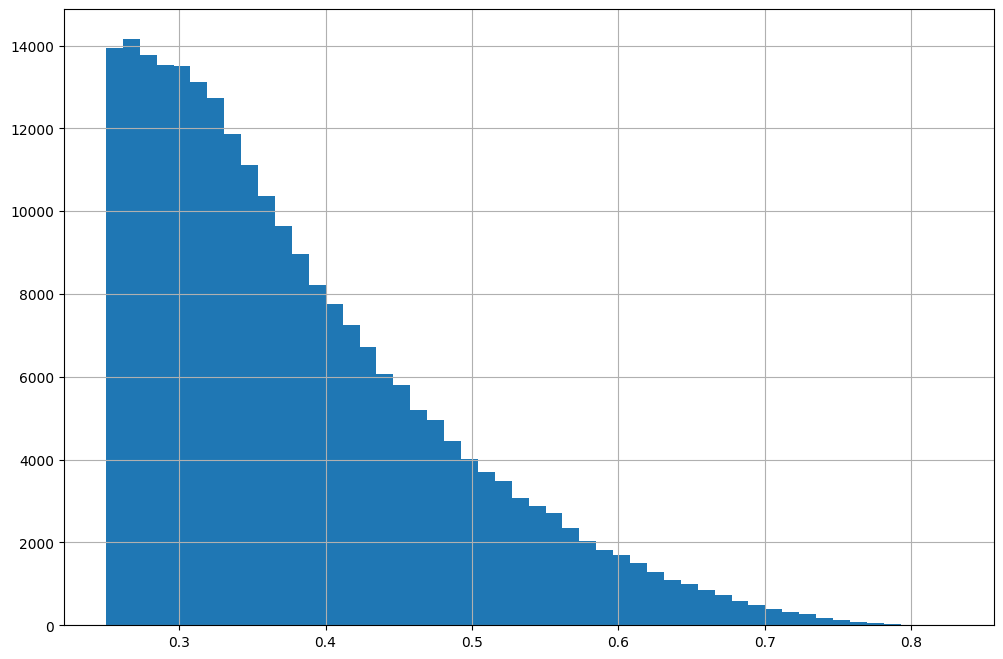

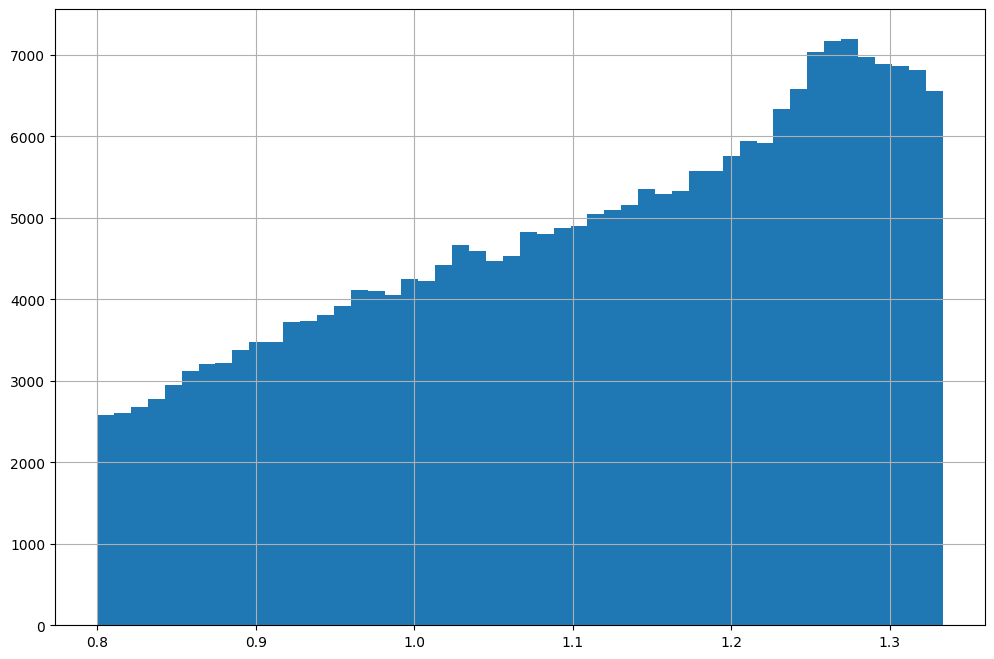

In [27]:
import matplotlib.pyplot as plt

df_train_filtered.call_price.hist(bins=50, figsize=(12,8))
plt.show()

df_train_filtered.S.hist(bins=50, figsize=(12,8))
plt.show()

### Test Data Transformation S -> S/K; c -> c/K; K -> 1

In [28]:
X_test_tf = X_test
y_test_tf = y_test

for i in range(0,N_test):

    #X_test[i] = [S,K,sigma,T,r,q]
    y_test_tf[i] = y_test[i] / X_test[i][1]
    X_test_tf[i][0] = X_test[i][0] / X_test[i][1]
    X_test_tf[i][1] = 1

In [29]:
# Eliminate test data with call_price < price_limit
#--------------------------------------------------

df_X_test_tf = pd.DataFrame(X_test_tf, columns = column_names)
df_y_test_tf = pd.DataFrame(y_test_tf, columns = ["call_price"])
df_test_tf = df_X_test_tf.copy()
df_test_tf['call_price'] = df_y_test_tf['call_price']

filter = (df_y_test_tf['call_price'] >= price_limit)

#print(filter)

X_test_filtered = df_X_test_tf[filter].to_numpy()
y_test_filtered = df_y_test_tf[filter].to_numpy()

In [30]:
X_test_filtered.shape

(60000, 6)

In [31]:
y_test_filtered.shape

(60000, 1)

In [32]:
# Filtered test data

df_test_filtered = df_test_tf[filter]

In [33]:
df_test_filtered.describe()

,S,K,sigma,T,r,q,call_price
count,60000.000000,60000.0,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,1.110174,1.0,0.613816,1.826265,0.020115,0.014596,0.382361
std,0.148652,0.0,0.206724,0.767839,0.005757,0.008660,0.103393
min,0.800001,1.0,0.050063,0.002808,0.010000,0.000002,0.250002
25%,0.991128,1.0,0.480029,1.252545,0.015171,0.007050,0.300327
50%,1.129190,1.0,0.653258,1.913380,0.020115,0.014440,0.357411
75%,1.241346,1.0,0.783649,2.481051,0.025134,0.022022,0.442293
max,1.333330,1.0,0.899999,2.999984,0.030000,0.030000,0.815531


In [34]:
print(df_test_filtered)

              S    K     sigma         T         r         q  call_price
0      1.231429  1.0  0.534953  1.995445  0.014654  0.010080    0.451022
1      0.921966  1.0  0.722366  1.483398  0.021847  0.025950    0.276360
2      0.941706  1.0  0.818707  2.136955  0.021045  0.001439    0.418187
3      1.311577  1.0  0.174019  0.207927  0.028329  0.016760    0.312894
4      0.900013  1.0  0.821450  1.277559  0.019443  0.009837    0.291463
...         ...  ...       ...       ...       ...       ...         ...
59995  1.183970  1.0  0.264645  2.989925  0.027522  0.002760    0.341708
59996  1.277395  1.0  0.556497  0.149463  0.024774  0.021469    0.292287
59997  1.265670  1.0  0.398594  0.548630  0.020478  0.005103    0.310882
59998  1.226283  1.0  0.223632  2.407061  0.027480  0.019610    0.290388
59999  1.302859  1.0  0.428629  0.307731  0.023824  0.019858    0.320001

[60000 rows x 7 columns]


In [35]:

# =============================================================================
# # Standardization of train and test Data
#
# from sklearn.preprocessing import StandardScaler
#
# scaler = StandardScaler()
# scaler.fit(X_train_tf)
#
# X_train_scaled = scaler.transform(X_train_tf)
# X_test_scaled = scaler.transform(X_test_tf)
# =============================================================================


## Neural Network definition and traning

In [36]:
# define the keras model
#-----------------------

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
import tensorflow as tf

# LeakyReLU Advanced Activation function
from tensorflow.keras.layers import LeakyReLU

# Model with 4 hidden layers (128, 128, 128, 128 cells)
model = Sequential()
model.add(Dense(128, input_dim=6, activation=LeakyReLU(alpha=0.1)))
model.add(Dropout(0.25))
model.add(Dense(128, activation='elu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='elu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='exponential'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# Compile model

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

In [38]:
# Train the model

history = model.fit(X_train_filtered, y_train_filtered, batch_size=64, epochs=15)

Epoch 1/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0079 - mean_absolute_error: 0.0548
Epoch 2/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 6.3553e-04 - mean_absolute_error: 0.0196
Epoch 3/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 3.8416e-04 - mean_absolute_error: 0.0151
Epoch 4/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 2.6682e-04 - mean_absolute_error: 0.0124
Epoch 5/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 2.2133e-04 - mean_absolute_error: 0.0113
Epoch 6/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 1.9676e-04 - mean_absolute_error: 0.0106
Epoch 7/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 1.9017e-04 - mean_absolute_error: 0.0105
Epoch 8/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 1.7954e-04 - mean_absolute_error: 0.0101
Epoch 9/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.7643e-04 - mean_absolute_error: 0.0101
Epoch 10/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.72

dict_keys(['loss', 'mean_absolute_error'])


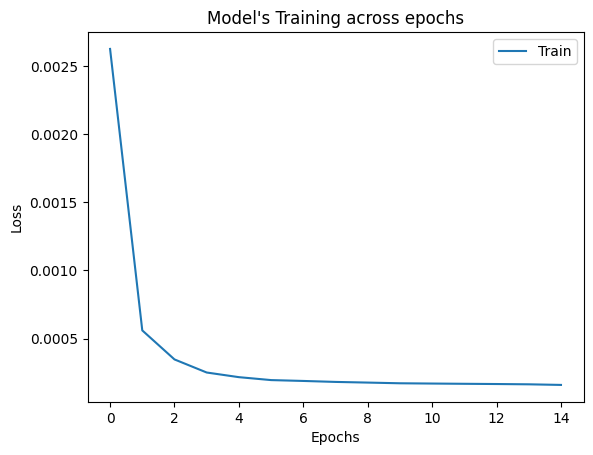

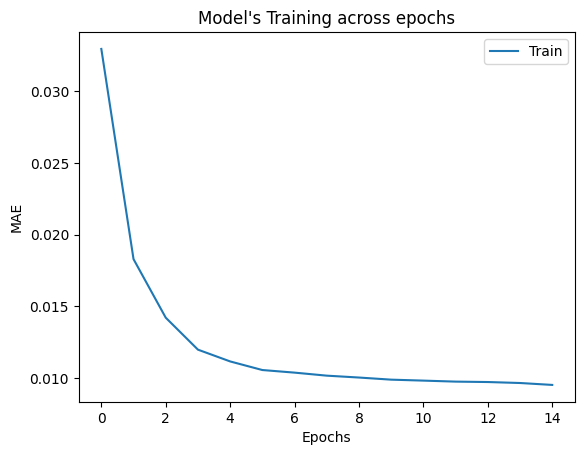

In [39]:
# Plot loss and MAE curves

import matplotlib.pyplot as plt

print(history.history.keys())

plt.plot(history.history['loss'])
plt.title("Model's Training across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train'], loc='upper right')
plt.show()

plt.plot(history.history['mean_absolute_error'])
plt.title("Model's Training across epochs")
plt.ylabel('MAE')
plt.xlabel('Epochs')
plt.legend(['Train'], loc='upper right')
plt.show()

## Model Quality

In [40]:
# Model result
Evaluation = model.evaluate(X_test_filtered, y_test_filtered)

for i in range(len(model.metrics_names)):
    print(model.metrics_names[i]," : ", Evaluation[i])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.3450e-05 - mean_absolute_error: 0.0048
loss  :  3.35386284859851e-05
compile_metrics  :  0.004766751546412706


In [41]:
# Prediction
y_predict = model.predict(X_test_filtered)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [42]:
# Comparison y_predit vs. y_test

df_y_predict = pd.DataFrame(y_predict, columns = ["y_predict"])
df_y_test_filtered = pd.DataFrame(y_test_filtered, columns = ["call_price"])
comparison = df_y_test_filtered.copy()
comparison["y_predict"] = df_y_predict["y_predict"]
comparison["error"] = (comparison.y_predict - comparison.call_price)
comparison["relative_err"] = np.absolute(comparison.error) / comparison.call_price

In [43]:
comparison.describe()

,call_price,y_predict,error,relative_err
count,60000.000000,60000.000000,60000.000000,6.000000e+04
mean,0.382361,0.386269,0.003908,1.261606e-02
std,0.103393,0.105077,0.004274,8.891515e-03
min,0.250002,0.250290,-0.037240,2.578807e-07
25%,0.300327,0.302153,0.001412,6.341414e-03
50%,0.357411,0.359371,0.003981,1.143917e-02
75%,0.442293,0.450321,0.006652,1.717777e-02
max,0.815531,0.800488,0.030567,1.176824e-01


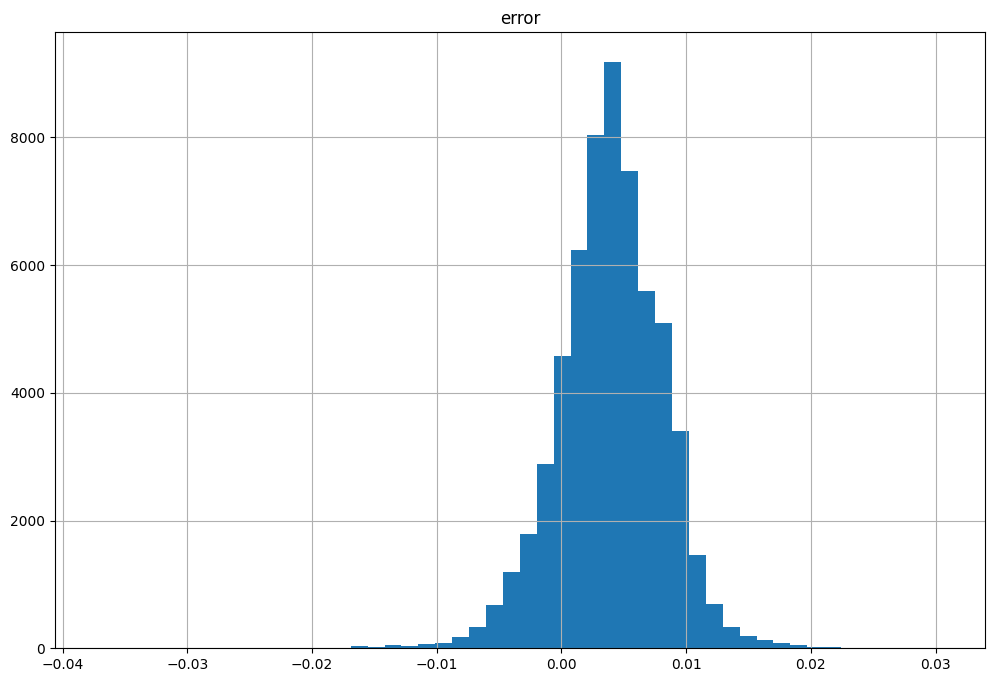

In [44]:
comparison[["error"]].hist(bins=50, figsize=(12,8))
plt.savefig('./images/ANN_BS_error')

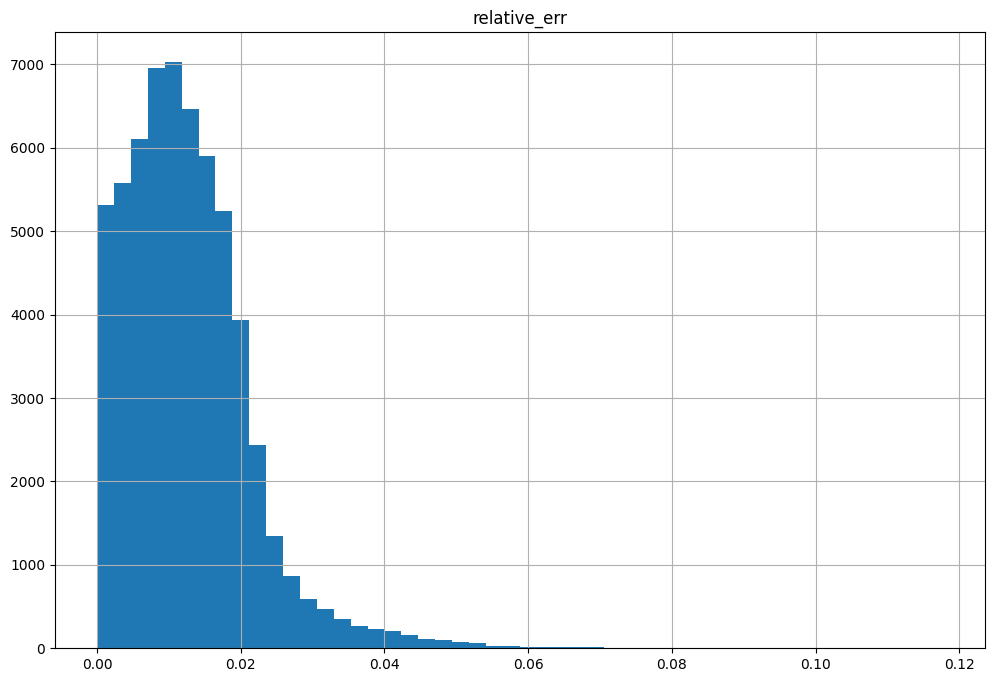

In [45]:
comparison[["relative_err"]].hist(bins=50, figsize=(12,8))
plt.savefig('./images/ANN_BS_relative_err')

In [46]:
comparison.head(25)

,call_price,y_predict,error,relative_err
0,0.451022,0.459479,0.008456,0.018749
1,0.276360,0.275459,-0.000901,0.003262
2,0.418187,0.425880,0.007693,0.018396
3,0.312894,0.314670,0.001776,0.005675
4,0.291463,0.293837,0.002375,0.008147
5,0.278353,0.283859,0.005506,0.019780
6,0.307484,0.308912,0.001428,0.004644
7,0.450630,0.456419,0.005789,0.012846
8,0.264229,0.268506,0.004276,0.016184
9,0.279012,0.281529,0.002516,0.009019


In [47]:
# Error analysis

relative_err_value = 0.05
filter = (comparison['relative_err'] >= relative_err_value)

analysis = comparison[filter]

len(analysis)

percentage = 100*len(analysis) / len(comparison)
print("relative_err_value <= ", relative_err_value, " : %.2f" %(100-percentage), "%")

relative_err_value <=  0.05  : 99.51 %


In [48]:
analysis.describe()

,call_price,y_predict,error,relative_err
count,296.000000,296.000000,296.000000,296.000000
mean,0.280036,0.285644,0.005608,0.060939
std,0.037254,0.023697,0.017044,0.012349
min,0.250002,0.262566,-0.037240,0.050038
25%,0.251908,0.265949,-0.015103,0.052126
50%,0.262720,0.278503,0.013503,0.056423
75%,0.291536,0.297099,0.015503,0.065788
max,0.398524,0.361284,0.030567,0.117682


In [49]:
print(analysis)

       call_price  y_predict     error  relative_err
101      0.287302   0.270686 -0.016616      0.057834
105      0.256946   0.273503  0.016556      0.064435
270      0.254885   0.267743  0.012858      0.050447
328      0.312137   0.295175 -0.016962      0.054343
392      0.285240   0.270439 -0.014800      0.051887
...           ...        ...       ...           ...
58461    0.398524   0.361284 -0.037240      0.093445
58465    0.256033   0.273554  0.017521      0.068431
58712    0.250031   0.263755  0.013724      0.054889
59312    0.260985   0.281821  0.020835      0.079834
59758    0.263184   0.284979  0.021795      0.082813

[296 rows x 4 columns]
